In [18]:
import matplotlib.pyplot as plt
from itertools import product
import igraph as ig
import numpy as np
from collections import defaultdict

%matplotlib inline

```
     F -- G -- H
    /      \\ /
   D         E
 /  \\      /
A -- B -- C
```

In [2]:
class KagomeLattice:
    def __init__(self, width=1, height=1):
        theta = np.pi / 3
        u = np.array([1, 0])
        v = np.array([np.cos(theta), np.sin(theta)])

        self.lattice_basis = np.c_[u, v]

        named_sites = {
            "A": np.array([0, 0]),
            "B": np.array([1, 0]),
            "C": np.array([2, 0]),
            "D": np.array([0, 1]),
            "E": np.array([2, 1]),
            "F": np.array([0, 2]),
            "G": np.array([1, 2]),
            "H": np.array([2, 2]),
        }

        named_edges = [
            ("AB", 1),
            ("BC", 1),
            ("AD", 1),
            ("BD", 2),
            ("DF", 1),
            ("FG", 1),
            ("GE", 2),
            ("GH", 1),
            ("EH", 1),
            ("CE", 1),
        ]

        edges = [
            ((named_sites[start], named_sites[end]), kind)
            for (start, end), kind in named_edges
        ]

        sites = []
        self.edges = []

        for i, j in product(range(width), range(height)):
            shift = 2 * np.array([i, j])
            for site in named_sites.values():
                sites.append(site + shift)
            for (start, end), kind in edges:
                self.edges.append(
                    (
                        (start + shift, end + shift),
                        kind,
                    )
                )

        self.site_to_num = {}
        new_num = 0
        for site in sites:
            canonical_coords = tuple(site % (2 * np.array([width, height])))
            if canonical_coords in self.site_to_num:
                self.site_to_num[tuple(site)] = self.site_to_num[canonical_coords]
            else:
                self.site_to_num[canonical_coords] = new_num
                self.site_to_num[tuple(site)] = new_num
                new_num += 1

        self.edges_to_kind = {}
        for (start, end), kind in self.edges:
            self.edges_to_kind[
                (self.site_to_num[tuple(start)], self.site_to_num[tuple(end)])
            ] = kind
            
    @property
    def sites(self):
        return sorted(set(self.site_to_num.values()))
    
    @property
    def kind_to_edges(self):
        k_to_e = defaultdict(list)
        for edge, kind in self.edges_to_kind.items():
            k_to_e[kind].append(edge)
        return k_to_e
            
    def as_igraph(self):
        edges, kinds = zip(*self.edges_to_kind.items())
        return ig.Graph(edges=edges, edge_attrs={'kind': kinds})
    
    def get_automorphisms(self):
        g = self.as_igraph()
        return g.get_automorphisms_vf2(edge_color=g.es['kind'])
                        
    def plot(self):
        for site, num in self.site_to_num.items():
            plt.plot(*(self.lattice_basis @ site), "o", color="C0")
            plt.annotate(str(num), self.lattice_basis @ site)
            
        for (start, end), kind in self.edges:
            plt.plot(
                *zip(self.lattice_basis @ start, self.lattice_basis @ end),
                color=f"C{kind}",
            )

lat.site_to_num.values()=dict_values([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 10, 0, 3, 11, 5, 8, 10, 0])
lat.kind_to_edges=defaultdict(<class 'list'>, {1: [(0, 1), (1, 2), (0, 3), (3, 5), (5, 6), (6, 7), (4, 7), (2, 4), (5, 8), (8, 0), (9, 2), (7, 9), (2, 10), (10, 0), (7, 11), (11, 5)], 2: [(1, 3), (6, 4), (6, 8), (1, 9), (10, 4), (11, 3), (11, 9), (10, 8)]})


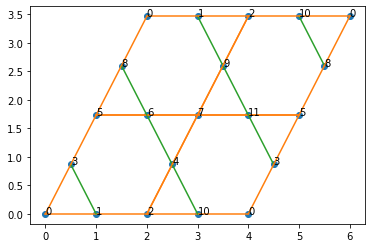

In [32]:
lat = KagomeLattice(width=2, height=2)
lat.plot()
# assert sorted(set(lat.site_to_num.values())) == list(range(24))
print(f"{lat.site_to_num.values()=}")
print(f"{lat.kind_to_edges=}")

In [12]:
import numpy as np
import scipy.sparse.linalg

import lattice_symmetries as ls


class HeisenbergJ1J2:
    def __init__(self, lat, J1=1., J2=1., use_symmetries=True):
        self.lat = lat
        
        number_spins = len(lat.sites)  # System size
        
        print(f"{number_spins=}")
        hamming_weight = number_spins // 2  # Hamming weight (i.e. number of spin ups)

        # Constructing symmetries

        if use_symmetries:
            symmetries = [ls.Symmetry(automorphism, sector=0) for automorphism in lat.get_automorphisms()]
        else:
            symmetries = []
        # Constructing the group
        self.symmetry_group = ls.Group(symmetries)
        print("Symmetry group contains {} elements".format(len(self.symmetry_group)))

        # Constructing the basis
        self.basis = ls.SpinBasis(
            self.symmetry_group,
            number_spins=number_spins,
            hamming_weight=hamming_weight,
            spin_inversion=1,
        )
        self.basis.build()  # Build the list of representatives, we need it since we're doing ED
        print("Hilbert space dimension is {}".format(self.basis.number_states))
        
        
        # Heisenberg Hamiltonian
        # fmt: off
        σ_x = np.array([ [0, 1]
                       , [1, 0] ])
        σ_y = np.array([ [0 , -1j]
                       , [1j,   0] ])
        σ_z = np.array([ [1,  0]
                       , [0, -1] ])
        # fmt: on
        σ_p = σ_x + 1j * σ_y
        σ_m = σ_x - 1j * σ_y

        matrix = 0.5 * (np.kron(σ_p, σ_m) + np.kron(σ_m, σ_p)) + np.kron(σ_z, σ_z)

        self.hamiltonian = ls.Operator(self.basis, 
                                       [ls.Interaction(J1 * matrix, lat.kind_to_edges[1]),
                                        ls.Interaction(J2 * matrix, lat.kind_to_edges[2])])
    
    def get_ground_state(self, k=1):
        # Diagonalize the Hamiltonian using ARPACK
        eigenvalues, eigenstates = ls.diagonalize(self.hamiltonian, k=k)
        print("Ground state energy is {:.10f}".format(eigenvalues[0]))
        return eigenvalues, eigenstates
        # assert np.isclose(eigenvalues[0], -18.06178542)

In [13]:
system = HeisenbergJ1J2(KagomeLattice(width=2, height=3))

number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102


In [14]:
system.get_ground_state()

Ground state energy is -31.0548143836


(array([-31.05481438]),
 array([[-1.00422423e-04],
        [ 8.67691074e-05],
        [ 5.75289280e-04],
        ...,
        [ 4.97225447e-02],
        [-3.22123989e-03],
        [-1.05731135e-02]]))

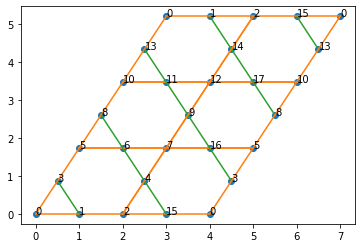

In [15]:
system.lat.plot()

In [34]:
vals, vecs = scipy.sparse.linalg.eigs(system.hamiltonian.to_csr(), k=1, which='SR')

In [35]:
vals

array([-31.05481438+0.j])